# Task 3: Forecasting Models

This notebook implements and compares three forecasting models for one-step-ahead prediction of mobile network traffic:

1. ARIMA
2. LSTM
3. GRU

The models are evaluated on three geographical areas:

- Highest traffic area
- Square 4159
- Square 4556

Performance is evaluated using MAE, RMSE and MAPE.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    GRU
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

## Load Dataset

In [2]:
df = pd.read_parquet(
    "/content/drive/MyDrive/mobile-dataset/milan_final.parquet"
)

df["datetime"] = pd.to_datetime(
    df["time_interval"],
    unit="ms"
)

df.head()

,square_id,time_interval,internet,datetime
0,1,1383260400000,11.028366,2013-10-31 23:00:00
1,1,1383261000000,11.127101,2013-10-31 23:10:00
2,1,1383261600000,10.892771,2013-10-31 23:20:00
3,1,1383262200000,8.622424,2013-10-31 23:30:00
4,1,1383262800000,8.009928,2013-10-31 23:40:00


## Identify Target Areas

In [3]:
# highest traffic square
traffic_by_square = (
    df.groupby("square_id")
      ["internet"]
      .sum()
)

highest_square = (
    traffic_by_square.idxmax()
)

highest_square

np.int16(5161)

In [4]:
# store areas

areas = [
    highest_square,
    4159,
    4556
]

areas

[np.int16(5161), 4159, 4556]

## Train-Test Split

In [5]:
def get_area_data(square_id):

    area = (
        df[df["square_id"] == square_id]
        .sort_values("datetime")
        .copy()
    )

    return area

def split_data(area):

    train = area[
        area["datetime"] < "2013-12-16"
    ]

    test = area[
        (area["datetime"] >= "2013-12-16")
        &
        (area["datetime"] < "2013-12-23")
    ]

    return train, test

# verif split

sample = get_area_data(
    highest_square
)

train, test = split_data(
    sample
)

print(len(train))
print(len(test))

6486
1008


## Data Normalization

In [6]:
def scale_data(
    train,
    test
):

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train.reshape(-1,1)
    )

    test_scaled = scaler.transform(
        test.reshape(-1,1)
    )

    return (
        train_scaled,
        test_scaled,
        scaler
    )

## Sequence Generation

In [7]:
def create_sequences(
    data,
    seq_len
):

    X = []
    y = []

    for i in range(
        len(data)-seq_len
    ):

        X.append(
            data[i:i+seq_len]
        )

        y.append(
            data[i+seq_len]
        )

    return (
        np.array(X),
        np.array(y)
    )

Hyperparameter Tuning Section

In [8]:
sequence_lengths = [
    12,
    24,
    48
]

## Hyperparameter Experimentation

Different sequence lengths were evaluated:

- 12 intervals
- 24 intervals
- 48 intervals

The final value was selected according to validation performance.

In [9]:
SEQ_LEN = 24

## ARIMA Model

ARIMA is a classical statistical forecasting model that combines autoregressive behavior, differencing, and moving average components.

The model is represented as ARIMA(p,d,q):

- p: autoregressive order
- d: differencing order
- q: moving average order

The model was selected as the statistical baseline for comparison with neural network models.

In [10]:
area_id = highest_square

area = get_area_data(
    area_id
)

train, test = split_data(
    area
)

# extract series

train_series = (
    train["internet"]
    .values
)

test_series = (
    test["internet"]
    .values
)

### ARIMA Hyperparameter Tuning

Different ARIMA configurations were evaluated experimentally.

The final order was selected according to validation error and model stability.

In [11]:
orders = [
    (1,1,1),
    (2,1,2),
    (3,1,3)
]

# training loop
results = []

for order in orders:

    start = time.time()

    model = ARIMA(
        train_series,
        order=order
    )

    fitted = model.fit()

    train_time = (
        time.time() - start
    )

    start_pred = time.time()

    predictions = fitted.forecast(
        steps=len(test_series)
    )

    pred_time = (
        time.time() - start_pred
    )

    mae = mean_absolute_error(
        test_series,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_series,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        test_series,
        predictions
    )

    results.append({
        "order": order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "train_time": train_time,
        "pred_time": pred_time
    })

# convert to table

results_df = pd.DataFrame(
    results
)

results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,MAE,RMSE,MAPE,train_time,pred_time
0,"(1, 1, 1)",1225.151674,1804.608740,0.653098,0.916726,0.063046
1,"(2, 1, 2)",1464.792995,2003.288355,1.036699,2.815947,0.032169
2,"(3, 1, 3)",1495.408991,2026.260080,1.105817,5.875832,0.035477


In [12]:
BEST_ORDER = (1,1,1)

# train again using best order

start_train = time.time()

arima_model = ARIMA(
    train_series,
    order=BEST_ORDER
)

arima_fitted = (
    arima_model.fit()
)

arima_train_time = (
    time.time() - start_train
)

In [13]:
# predict
start_pred = time.time()

arima_predictions = (
    arima_fitted.forecast(
        steps=len(test_series)
    )
)

arima_pred_time = (
    time.time() - start_pred
)

In [14]:
# metrics
arima_mae = mean_absolute_error(
    test_series,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test_series,
        arima_predictions
    )
)

arima_mape = (
    mean_absolute_percentage_error(
        test_series,
        arima_predictions
    )
)

print("ARIMA Results")

print(
    f"MAE: {arima_mae:.4f}"
)

print(
    f"RMSE: {arima_rmse:.4f}"
)

print(
    f"MAPE: {arima_mape:.4f}"
)

print(
    f"Training Time: "
    f"{arima_train_time:.2f} sec"
)

print(
    f"Prediction Time: "
    f"{arima_pred_time:.2f} sec"
)

ARIMA Results
MAE: 1225.1517
RMSE: 1804.6087
MAPE: 0.6531
Training Time: 0.35 sec
Prediction Time: 0.03 sec


### ARIMA Forecasting Results

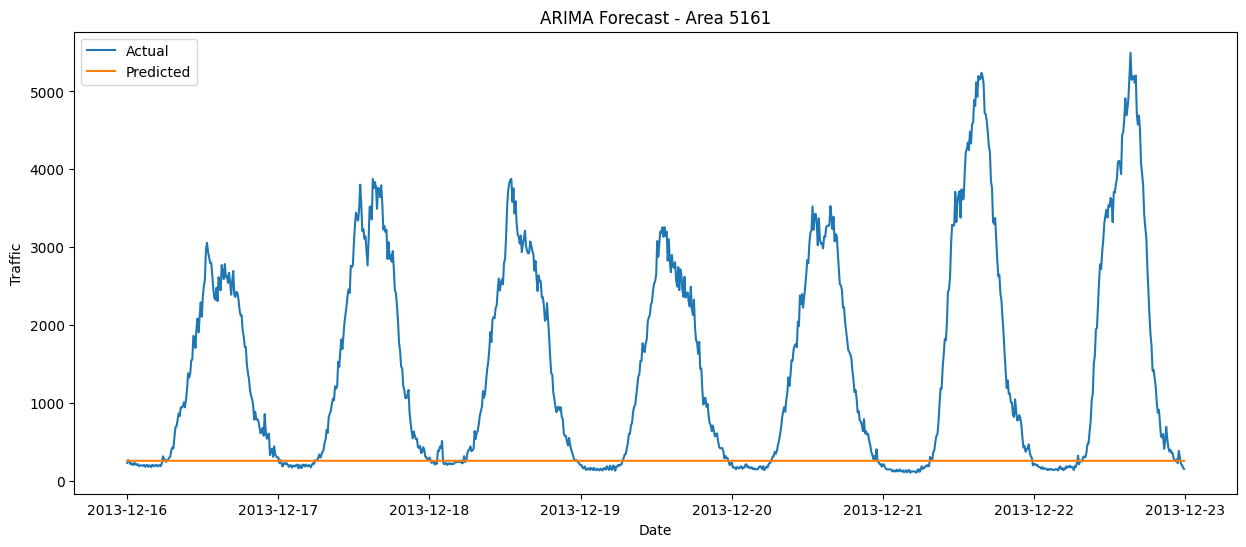

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    test["datetime"],
    test_series,
    label="Actual"
)

plt.plot(
    test["datetime"],
    arima_predictions,
    label="Predicted"
)

plt.title(
    f"ARIMA Forecast - Area {area_id}"
)

plt.xlabel("Date")

plt.ylabel("Traffic")

plt.legend()

plt.show()

In [16]:
# save metrics
arima_metrics = {
    "Model": "ARIMA",
    "MAE": arima_mae,
    "RMSE": arima_rmse,
    "MAPE": arima_mape,
    "Train Time": arima_train_time,
    "Prediction Time": arima_pred_time
}

## LSTM Model

Long Short-Term Memory (LSTM) networks are a specialized form of recurrent neural network designed to learn long-term temporal dependencies.

Unlike ARIMA, LSTM can model nonlinear relationships and complex sequential patterns, making it suitable for mobile network traffic forecasting.

In [17]:
SEQ_LEN = 24

# extract data
area_id = highest_square

area = get_area_data(
    area_id
)

train, test = split_data(
    area
)

# series
train_values = (
    train["internet"]
    .values
)

test_values = (
    test["internet"]
    .values
)

In [37]:
# scale data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_values.reshape(-1,1)
)

test_scaled = scaler.transform(
    test_values.reshape(-1,1)
)

# create sequences
X_train, y_train = create_sequences(
    train_scaled,
    SEQ_LEN
)


X_test, y_test = create_sequences(
    test_scaled,
    SEQ_LEN
)

print(X_train.shape)
print(y_train.shape)

(6462, 24, 1)
(6462, 1)


In [48]:
# build lstm architecture
lstm_model = Sequential()

# add lstm layer
lstm_model.add(
    LSTM(
        50,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

#Dense layer for single-step prediction
lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# compile
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [50]:
# train model
start_train = time.time()

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0116 - val_loss: 0.0030
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 9.2822e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.7628e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.6486e-04
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.3253e-04
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 8.2768e-04
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0010 - val_loss: 7.0365e-04
Epoch 10/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 6.7938e-04
Epoch 11/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.9189e-04 - val_loss: 6.8991e-04
Epoch 12/30
81/81 ━━━━━━━━━━━━━━━━━━━━

In [51]:
lstm_train_time = (
    time.time() - start_train
)

print(lstm_train_time)

24.31560182571411


gyper parameter tuning

In [92]:
lstm_model_2 = Sequential()

# add lstm layer
lstm_model_2.add(
    LSTM(
        100,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

lstm_model_2.add(Dense(1))

lstm_model_2.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# compile
lstm_model_2.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [94]:
start_train_2 = time.time()

history_2 = lstm_model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0064 - val_loss: 0.0011
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 8.9489e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.3219e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.4106e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.4117e-04
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0010 - val_loss: 6.7670e-04
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 6.7188e-04
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7028e-04 - val_loss: 7.1906e-04
Epoch 10/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.6955e-04 - val_loss: 6.8202e-04
Epoch 11/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.5442e-04 - val_loss: 5.8370e-04
Epoch 12/30
81/81 ━━━━━━━━

In [88]:
lstm_model_3 = Sequential()

# add lstm layer
lstm_model_3.add(
    LSTM(
        32,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

lstm_model_3.add(Dense(1))

lstm_model_3.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
# compile
lstm_model_3.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [90]:
start_train_3 = time.time()

history_3 = lstm_model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0129 - val_loss: 0.0023
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 9.3772e-04
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.6727e-04
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 8.2305e-04
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.9636e-04
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 7.3960e-04
Epoch 10/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 7.2353e-04
Epoch 11/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 7.8675e-04
Epoch 12/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/

In [123]:
# predict
start_pred = time.time()

lstm_predictions = (
    lstm_model.predict(
        X_test
    )
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [124]:
lstm_pred_time = (
    time.time() - start_pred
)

In [125]:
lstm_predictions = (
    scaler.inverse_transform(
        lstm_predictions
    )
)

In [126]:
y_test_actual = (
    scaler.inverse_transform(
        y_test
    )
)

In [127]:
# metrics
lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

In [128]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

In [129]:
lstm_mape = (
    mean_absolute_percentage_error(
        y_test_actual,
        lstm_predictions
    )
)

In [130]:
print(
    f"MAE: {lstm_mae:.4f}"
)

print(
    f"RMSE: {lstm_rmse:.4f}"
)

print(
    f"MAPE: {lstm_mape:.4f}"
)

print(
    f"Training Time: {lstm_train_time:.2f}"
)

print(
    f"Prediction Time: {lstm_pred_time:.2f}"
)

MAE: 94.1260
RMSE: 137.9143
MAPE: 0.0980
Training Time: 24.32
Prediction Time: 2.40


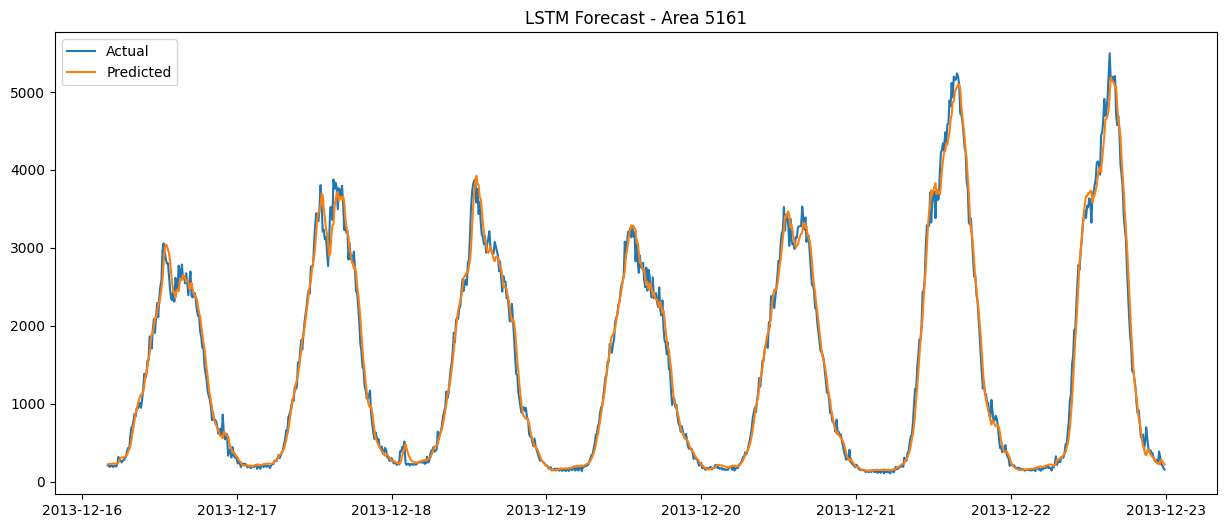

In [131]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    test["datetime"][SEQ_LEN:],
    y_test_actual,
    label="Actual"
)

plt.plot(
    test["datetime"][SEQ_LEN:],
    lstm_predictions,
    label="Predicted"
)

plt.title(
    f"LSTM Forecast - Area {area_id}"
)

plt.legend()

plt.show()

In [132]:
lstm_metrics = {
    "Model":"LSTM",
    "MAE":lstm_mae,
    "RMSE":lstm_rmse,
    "MAPE":lstm_mape,
    "Train Time":lstm_train_time,
    "Prediction Time":lstm_pred_time
}

## GRU Model

The Gated Recurrent Unit (GRU) is a recurrent neural network architecture designed to capture temporal dependencies in sequential data.

Compared with LSTM, GRU uses fewer gating mechanisms and therefore contains fewer trainable parameters. This often results in faster training while maintaining comparable predictive performance.

In [186]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(
    GRU(
        50,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

gru_model.add(
    Dense(1)
)

gru_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_9 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
gru_model.compile(
    optimizer="adam",
    loss="mse"
)

In [188]:
start_train = time.time()

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0050 - val_loss: 0.0012
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 8.7750e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 6.6984e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.7558e-04 - val_loss: 5.7891e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.1849e-04 - val_loss: 5.2438e-04


In [189]:
gru_train_time = (
    time.time()
    - start_train
)
print(gru_train_time)

10.149412393569946


In [190]:
start_pred = time.time()

gru_predictions = (
    gru_model.predict(
        X_test
    )
)

gru_pred_time = (
    time.time()
    - start_pred
)
print(gru_pred_time)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
0.29613208770751953


GRU hyper parameter tunning

In [199]:
gru_model_2 = Sequential()

gru_model_2.add(
    GRU(
        100,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

gru_model_2.add(
    Dense(1)
)

gru_model_2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 100)            │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,001 (121.10 KB)

 Trainable params: 31,001 (121.10 KB)

 Non-trainable params: 0 (0.00 B)

In [200]:
gru_model_2.compile(
    optimizer="adam",
    loss="mse"
)

In [201]:
start_train_2 = time.time()

history_gru_2 = gru_model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0063 - val_loss: 0.0014
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 9.1809e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 6.5581e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9504e-04 - val_loss: 5.7445e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.5938e-04 - val_loss: 5.5873e-04


In [202]:
gru_train_time_2= (
    time.time()
    - start_train_2
)

In [203]:
gru_model_3 = Sequential()

gru_model_3.add(
    GRU(
        32,
        input_shape=(
            SEQ_LEN,
            1
        )
    )
)

gru_model_3.add(
    Dense(1)
)

gru_model_3.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [204]:
gru_model_3.compile(
    optimizer="adam",
    loss="mse"
)

In [205]:
start_train_3 = time.time()

history_gru_3 = gru_model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0138 - val_loss: 0.0021
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 8.5258e-04
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.0368e-04


In [206]:
gru_train_time_3= (
    time.time()
    - start_train_3
)

GRU prediction

In [191]:
start_pred = time.time()

gru_predictions = (
    gru_model.predict(
        X_test
    )
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [192]:
gru_pred_time = (
    time.time()
    - start_pred
)

undo scaling

In [193]:
gru_predictions = (
    scaler.inverse_transform(
        gru_predictions
    )
)

y_test_actual = (
    scaler.inverse_transform(
        y_test
    )
)

metrics

In [194]:
gru_mae = mean_absolute_error(
    y_test_actual,
    gru_predictions
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_predictions
    )
)

gru_mape = (
    mean_absolute_percentage_error(
        y_test_actual,
        gru_predictions
    )
)

In [195]:
print("GRU Results")

print(
    f"MAE: {gru_mae:.4f}"
)

print(
    f"RMSE: {gru_rmse:.4f}"
)

print(
    f"MAPE: {gru_mape:.4f}"
)

print(
    f"Training Time: {gru_train_time:.2f}"
)

print(
    f"Prediction Time: {gru_pred_time:.2f}"
)

GRU Results
MAE: 177.3306
RMSE: 230.3246
MAPE: 0.2345
Training Time: 10.15
Prediction Time: 2.53


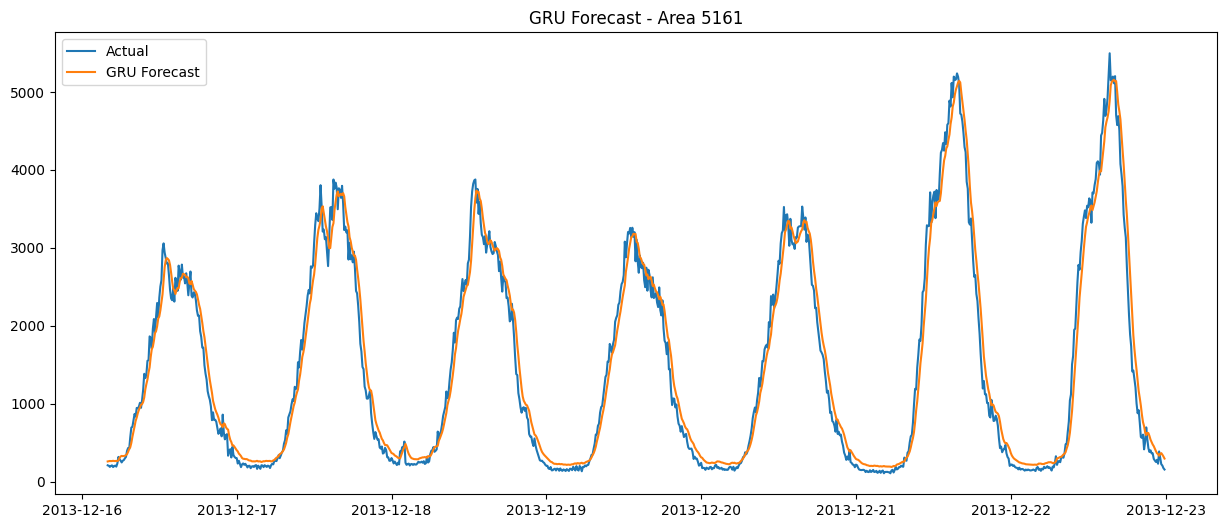

In [196]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    test["datetime"][SEQ_LEN:],
    y_test_actual,
    label="Actual"
)

plt.plot(
    test["datetime"][SEQ_LEN:],
    gru_predictions,
    label="GRU Forecast"
)

plt.title(
    f"GRU Forecast - Area {area_id}"
)

plt.legend()

plt.show()

In [197]:
gru_metrics = {
    "Model":"GRU",
    "MAE":gru_mae,
    "RMSE":gru_rmse,
    "MAPE":gru_mape,
    "Train Time":gru_train_time,
    "Prediction Time":gru_pred_time
}

comparison of all models

In [198]:
comparison = pd.DataFrame([
    arima_metrics,
    lstm_metrics,
    gru_metrics
])

comparison

,Model,MAE,RMSE,MAPE,Train Time,Prediction Time
0,ARIMA,1225.151674,1804.608740,0.653098,0.350917,0.032346
1,LSTM,94.125954,137.914347,0.097976,24.315602,2.399026
2,GRU,177.330597,230.324618,0.234525,10.149412,2.529358


# Model Evaluation Across All Target Areas

To ensure fairness, all forecasting models were applied to the same three geographical areas:

- Highest traffic area
- Area 4159
- Area 4556

For each area, ARIMA, LSTM and GRU were trained independently using identical train-test splits.

Performance was evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Training and prediction times were also recorded.

In [207]:

# define areas
target_areas = [
    highest_square,
    4159,
    4556
]

ARIMA function

In [209]:
def run_arima(area_id):

    area = get_area_data(area_id)

    train, test = split_data(area)

    train_series = train["internet"].values

    test_series = test["internet"].values

    start_train = time.time()

    model = ARIMA(
        train_series,
        order=(1,1,1)
    )

    fitted = model.fit()

    train_time = (
        time.time() - start_train
    )

    start_pred = time.time()

    predictions = fitted.forecast(
        steps=len(test_series)
    )

    pred_time = (
        time.time() - start_pred
    )

    mae = mean_absolute_error(
        test_series,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_series,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        test_series,
        predictions
    )

    return {
        "Area": area_id,
        "Model": "ARIMA",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Train Time": train_time,
        "Prediction Time": pred_time
    }

LSTM function

In [210]:
def run_lstm(area_id):

    area = get_area_data(area_id)

    train,test = split_data(area)

    train_values = train["internet"].values

    test_values = test["internet"].values

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train_values.reshape(-1,1)
    )

    test_scaled = scaler.transform(
        test_values.reshape(-1,1)
    )

    X_train,y_train = create_sequences(
        train_scaled,
        SEQ_LEN
    )

    X_test,y_test = create_sequences(
        test_scaled,
        SEQ_LEN
    )

    model = Sequential()

    model.add(
        LSTM(
            50,
            input_shape=(
                SEQ_LEN,
                1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    start_train = time.time()

    model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = (
        time.time() - start_train
    )

    start_pred = time.time()

    predictions = model.predict(
        X_test,
        verbose=0
    )

    pred_time = (
        time.time() - start_pred
    )

    predictions = scaler.inverse_transform(
        predictions
    )

    y_test_actual = scaler.inverse_transform(
        y_test
    )

    mae = mean_absolute_error(
        y_test_actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        y_test_actual,
        predictions
    )

    return {
        "Area": area_id,
        "Model": "LSTM",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Train Time": train_time,
        "Prediction Time": pred_time
    }

GRU function

In [211]:
def run_gru(area_id):

    area = get_area_data(area_id)

    train,test = split_data(area)

    train_values = train["internet"].values

    test_values = test["internet"].values

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train_values.reshape(-1,1)
    )

    test_scaled = scaler.transform(
        test_values.reshape(-1,1)
    )

    X_train,y_train = create_sequences(
        train_scaled,
        SEQ_LEN
    )

    X_test,y_test = create_sequences(
        test_scaled,
        SEQ_LEN
    )

    model = Sequential()

    model.add(
        GRU(
            50,
            input_shape=(
                SEQ_LEN,
                1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    start_train = time.time()

    model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = (
        time.time() - start_train
    )

    start_pred = time.time()

    predictions = model.predict(
        X_test,
        verbose=0
    )

    pred_time = (
        time.time() - start_pred
    )

    predictions = scaler.inverse_transform(
        predictions
    )

    y_test_actual = scaler.inverse_transform(
        y_test
    )

    mae = mean_absolute_error(
        y_test_actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        y_test_actual,
        predictions
    )

    return {
        "Area": area_id,
        "Model": "GRU",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Train Time": train_time,
        "Prediction Time": pred_time
    }

run on all areas

In [212]:
all_results = []

for area in target_areas:

    print(
        f"\nProcessing Area {area}"
    )

    all_results.append(
        run_arima(area)
    )

    all_results.append(
        run_lstm(area)
    )

    all_results.append(
        run_gru(area)
    )


Processing Area 5161

Processing Area 4159

Processing Area 4556


In [213]:
results_df = pd.DataFrame(
    all_results
)

results_df

,Area,Model,MAE,RMSE,MAPE,Train Time,Prediction Time
0,5161,ARIMA,1225.151674,1804.608740,0.653098,0.343280,0.028788
1,5161,LSTM,93.890244,134.679879,0.112939,19.288772,0.292687
2,5161,GRU,89.243744,131.529167,0.086757,11.483804,0.363581
3,4159,ARIMA,107.362011,149.888279,0.357299,1.511934,0.036107
4,4159,LSTM,15.288155,20.343397,0.069492,18.889683,0.292914
5,4159,GRU,14.987229,20.184769,0.066215,17.361998,0.273192
6,4556,ARIMA,143.606167,174.030480,0.346007,0.409736,0.032387
7,4556,LSTM,28.277983,37.149983,0.067233,15.699679,0.397048
8,4556,GRU,27.518358,36.589030,0.063535,15.112170,0.302050


In [214]:
results_df.to_csv(
    "/content/drive/MyDrive/all_model_results.csv",
    index=False
)

In [215]:
results_df.sort_values(
    by="RMSE"
)

,Area,Model,MAE,RMSE,MAPE,Train Time,Prediction Time
5,4159,GRU,14.987229,20.184769,0.066215,17.361998,0.273192
4,4159,LSTM,15.288155,20.343397,0.069492,18.889683,0.292914
8,4556,GRU,27.518358,36.589030,0.063535,15.112170,0.302050
7,4556,LSTM,28.277983,37.149983,0.067233,15.699679,0.397048
2,5161,GRU,89.243744,131.529167,0.086757,11.483804,0.363581
1,5161,LSTM,93.890244,134.679879,0.112939,19.288772,0.292687
3,4159,ARIMA,107.362011,149.888279,0.357299,1.511934,0.036107
6,4556,ARIMA,143.606167,174.030480,0.346007,0.409736,0.032387
0,5161,ARIMA,1225.151674,1804.608740,0.653098,0.343280,0.028788


# Best Performing Model Per Area

For each geographical area, the model with the lowest RMSE was selected as the best-performing forecasting model.

RMSE was chosen because it penalizes large prediction errors more strongly than MAE.

In [216]:
best_models = (
    results_df
    .sort_values("RMSE")
    .groupby("Area")
    .first()
    .reset_index()
)

best_models

,Area,Model,MAE,RMSE,MAPE,Train Time,Prediction Time
0,4159,GRU,14.987229,20.184769,0.066215,17.361998,0.273192
1,4556,GRU,27.518358,36.589030,0.063535,15.112170,0.302050
2,5161,GRU,89.243744,131.529167,0.086757,11.483804,0.363581


### RMSE Comparison

Lower RMSE values indicate better forecasting performance.

This visualization compares forecasting accuracy across all models and geographical areas.

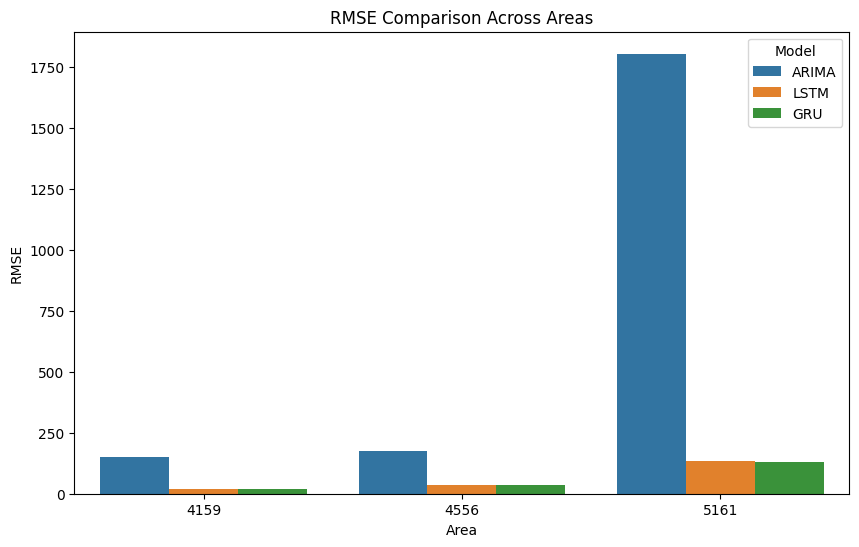

In [217]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Area",
    y="RMSE",
    hue="Model"
)

plt.title("RMSE Comparison Across Areas")

plt.show()

### MAE Comparison

MAE measures the average magnitude of forecasting errors.

Lower values indicate more accurate predictions.

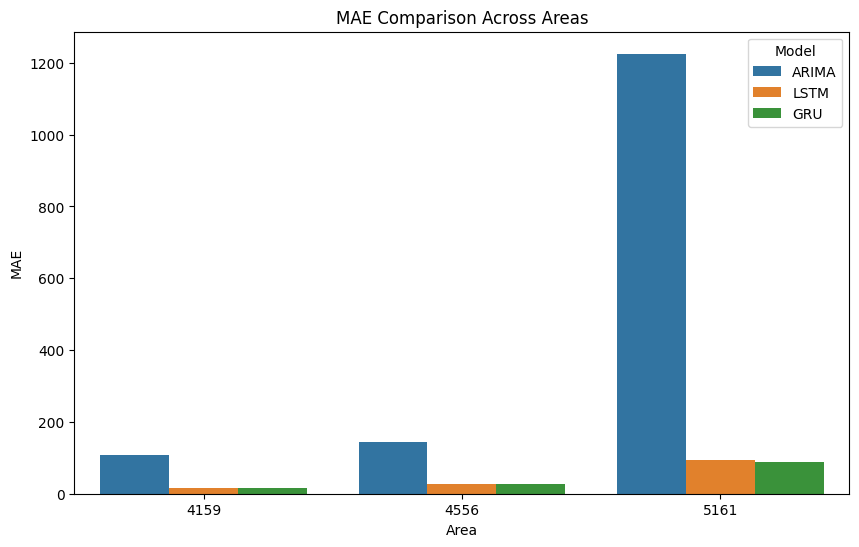

In [218]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Area",
    y="MAE",
    hue="Model"
)

plt.title("MAE Comparison Across Areas")

plt.show()

### Computational Cost

Training time was recorded to evaluate computational efficiency.

While deep learning models may achieve better forecasting accuracy, they generally require more training time than traditional statistical models.

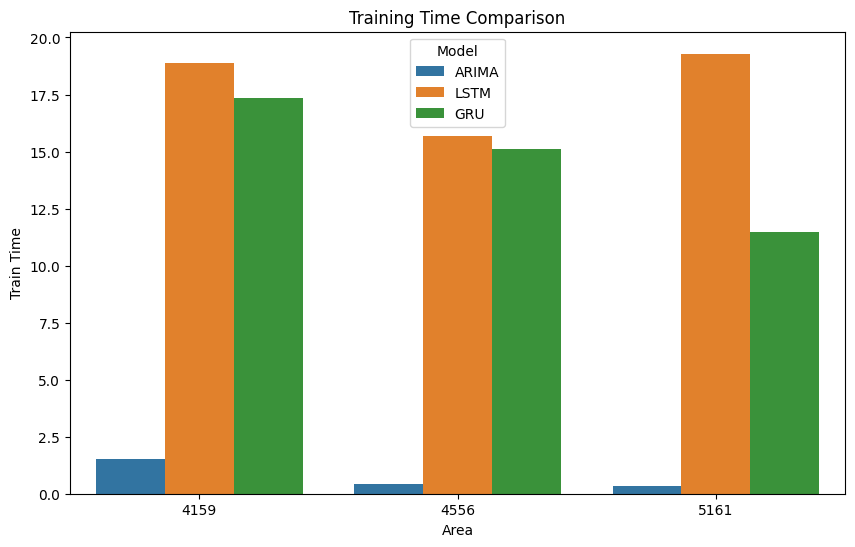

In [219]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Area",
    y="Train Time",
    hue="Model"
)

plt.title("Training Time Comparison")

plt.show()

# Overall Ranking

The average performance across all geographical areas was computed to determine the overall best forecasting model.

The model with the lowest average RMSE is considered the strongest performer.

In [220]:
overall_ranking = (
    results_df
    .groupby("Model")[["MAE","RMSE","MAPE"]]
    .mean()
    .sort_values("RMSE")
)

overall_ranking

,MAE,RMSE,MAPE
Model,,,
GRU,43.916444,62.767655,0.072169
LSTM,45.818794,64.057753,0.083221
ARIMA,492.039951,709.509166,0.452135
